In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Fraud_Analysis_Dataset.csv')
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [3]:
#EDA
df.shape

(11142, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [6]:
#statistics
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [7]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    89.750494
1    10.249506
Name: proportion, dtype: float64

<Axes: xlabel='type', ylabel='count'>

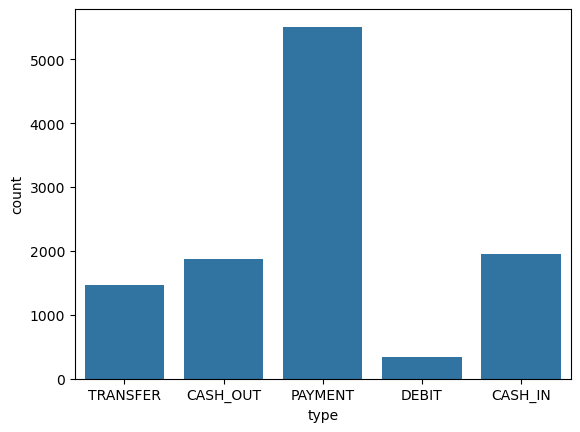

In [8]:
import seaborn as sns
sns.countplot(x='type',data=df)

<Axes: ylabel='amount'>

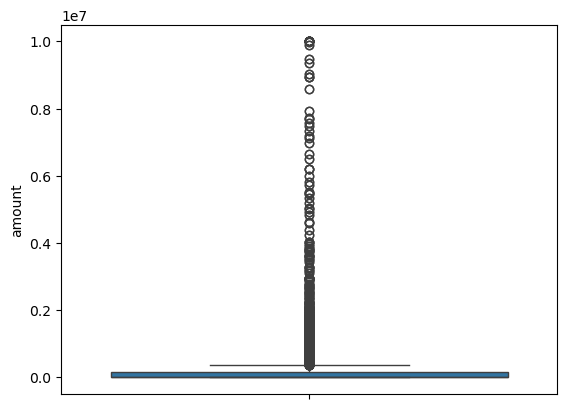

In [9]:
sns.boxplot(y=df['amount'])

In [10]:
df=df.drop(['nameOrig','nameDest','step','oldbalanceOrg','newbalanceOrig'],axis=1)
df.head()

,type,amount,oldbalanceDest,newbalanceDest,isFraud
0,TRANSFER,181.0,0.0,0.0,1
1,CASH_OUT,181.0,21182.0,0.0,1
2,TRANSFER,2806.0,0.0,0.0,1
3,CASH_OUT,2806.0,26202.0,0.0,1
4,TRANSFER,20128.0,0.0,0.0,1


In [11]:
df=pd.get_dummies(df,drop_first=True,dtype='int')
df

,amount,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,0.00,0.00,1,0,0,0,1
1,181.00,21182.00,0.00,1,1,0,0,0
2,2806.00,0.00,0.00,1,0,0,0,1
3,2806.00,26202.00,0.00,1,1,0,0,0
4,20128.00,0.00,0.00,1,0,0,0,1
...,...,...,...,...,...,...,...,...
11137,6393.71,478421.00,210535.25,0,0,1,0,0
11138,298799.54,704355.36,5270364.19,0,1,0,0,0
11139,423159.63,610479.00,749621.53,0,1,0,0,0
11140,1094.03,0.00,0.00,0,0,0,1,0


In [12]:
x=df.drop('isFraud',axis=1)
y=df.isFraud

In [13]:
x

,amount,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,0.00,0.00,0,0,0,1
1,181.00,21182.00,0.00,1,0,0,0
2,2806.00,0.00,0.00,0,0,0,1
3,2806.00,26202.00,0.00,1,0,0,0
4,20128.00,0.00,0.00,0,0,0,1
...,...,...,...,...,...,...,...
11137,6393.71,478421.00,210535.25,0,1,0,0
11138,298799.54,704355.36,5270364.19,1,0,0,0
11139,423159.63,610479.00,749621.53,1,0,0,0
11140,1094.03,0.00,0.00,0,0,1,0


In [14]:
y

0        1
1        1
2        1
3        1
4        1
        ..
11137    0
11138    0
11139    0
11140    0
11141    0
Name: isFraud, Length: 11142, dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
x_scale=scaler.fit_transform(x)
x_scale

array([[-0.28026556, -0.34150926, -0.36991804, ..., -0.17902209,
        -0.98910974,  2.57111955],
       [-0.28026556, -0.33336628, -0.36991804, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27681175, -0.34150926, -0.36991804, ..., -0.17902209,
        -0.98910974,  2.57111955],
       ...,
       [ 0.27626264, -0.1068233 , -0.11856231, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27906425, -0.34150926, -0.36991804, ..., -0.17902209,
         1.01101017, -0.38893563],
       [-0.26835212, -0.34150926, -0.36991804, ..., -0.17902209,
         1.01101017, -0.38893563]])

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,random_state=70,test_size=0.3)

In [18]:
from sklearn.linear_model import LogisticRegression
lgr=LogisticRegression()

In [19]:
lgr.fit(x_train,y_train)

LogisticRegression()

In [20]:
y_pred=lgr.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score,roc_auc_score
accuracy=accuracy_score(y_pred,y_test)
accuracy

0.9323960514507927

In [22]:
precision=precision_score(y_pred,y_test)
print("precision",precision)
recall=recall_score(y_pred,y_test)
print("recall",recall)
f1_score=f1_score(y_pred,y_test)
print("f1_score",f1_score)
rocauc=roc_auc_score(y_pred,y_test)
print("roc",rocauc)

precision 0.3704819277108434
recall 0.8785714285714286
f1_score 0.5211864406779662
roc 0.9066600508451897


In [23]:
confusion=confusion_matrix(y_pred,y_test)
confusion

array([[2994,  209],
       [  17,  123]], dtype=int64)

In [24]:
print(lgr.intercept_)

[-6.18504062]


In [25]:
print(lgr.coef_)

[[ 1.51498287  0.45369239 -1.78481795  2.37065042 -0.25226479 -0.77631611
   2.1163167 ]]


In [26]:
clf=classification_report(y_pred,y_test)
clf

'              precision    recall  f1-score   support\n\n           0       0.99      0.93      0.96      3203\n           1       0.37      0.88      0.52       140\n\n    accuracy                           0.93      3343\n   macro avg       0.68      0.91      0.74      3343\nweighted avg       0.97      0.93      0.95      3343\n'

In [27]:
print(clf)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      3203
           1       0.37      0.88      0.52       140

    accuracy                           0.93      3343
   macro avg       0.68      0.91      0.74      3343
weighted avg       0.97      0.93      0.95      3343



In [28]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lgr.coef_[0],
    'Importance': abs(lgr.coef_[0])
}).sort_values(by='Importance', ascending=False)

print(importance)

          Feature  Coefficient  Importance
3   type_CASH_OUT     2.370650    2.370650
6   type_TRANSFER     2.116317    2.116317
2  newbalanceDest    -1.784818    1.784818
0          amount     1.514983    1.514983
5    type_PAYMENT    -0.776316    0.776316
1  oldbalanceDest     0.453692    0.453692
4      type_DEBIT    -0.252265    0.252265


In [42]:
lgr.coef_[0]

array([ 1.51498287,  0.45369239, -1.78481795,  2.37065042, -0.25226479,
       -0.77631611,  2.1163167 ])

In [29]:
importance['Rank'] = importance['Importance'].rank(ascending=False)
print(importance)

          Feature  Coefficient  Importance  Rank
3   type_CASH_OUT     2.370650    2.370650   1.0
6   type_TRANSFER     2.116317    2.116317   2.0
2  newbalanceDest    -1.784818    1.784818   3.0
0          amount     1.514983    1.514983   4.0
5    type_PAYMENT    -0.776316    0.776316   5.0
1  oldbalanceDest     0.453692    0.453692   6.0
4      type_DEBIT    -0.252265    0.252265   7.0


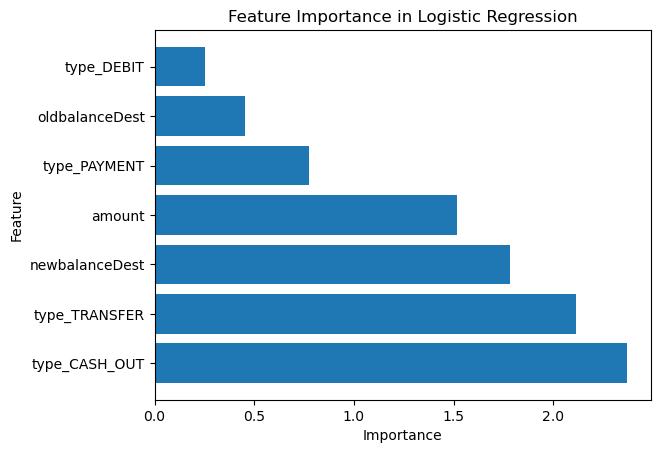

In [30]:
import matplotlib.pyplot as plt

plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Logistic Regression")
plt.show()


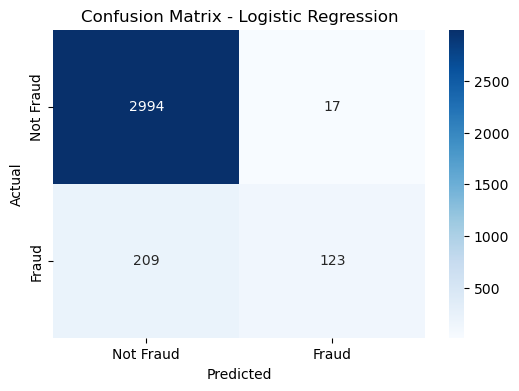

In [31]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['Not Fraud','Fraud'], yticklabels=['Not Fraud','Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

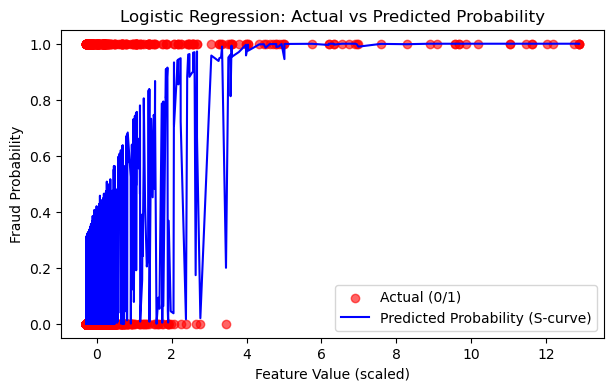

In [32]:
import matplotlib.pyplot as plt

# Get probabilities for class 1 (fraud = 1)
y_prob = lgr.predict_proba(x_test)[:,1]

# Pick one feature (say the first column)
x_feature = x_test[:,0]  

# Sort values for smooth curve
sorted_idx = x_feature.argsort()
plt.figure(figsize=(7,4))
plt.scatter(x_feature, y_test, color="red", label="Actual (0/1)", alpha=0.6)
plt.plot(x_feature[sorted_idx], y_prob[sorted_idx], color="blue", label="Predicted Probability (S-curve)")

plt.xlabel("Feature Value (scaled)")
plt.ylabel("Fraud Probability")
plt.title("Logistic Regression: Actual vs Predicted Probability")
plt.legend()
plt.show()


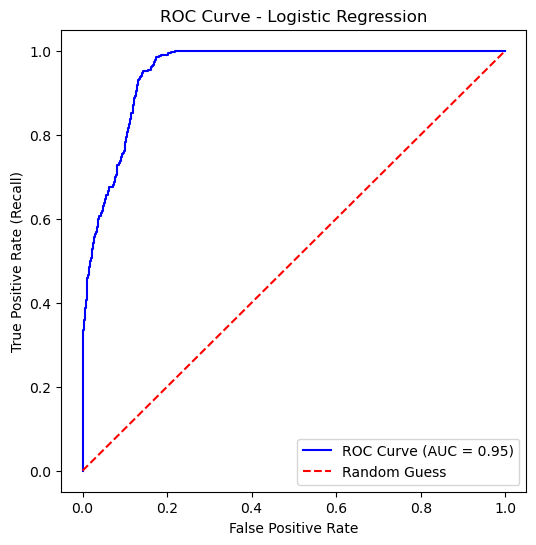

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for class 1 (fraud = 1)
y_prob = lgr.predict_proba(x_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


In [34]:
from sklearn.metrics import f1_score

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1 Score:", best_f1)


Best Threshold: 0.35604783872647283
Best F1 Score: 0.6191950464396285


In [35]:
thresholds

array([           inf, 9.99999994e-01, 7.42050840e-01, 7.32828135e-01,
       7.30325178e-01, 7.21222833e-01, 6.86833884e-01, 6.82845983e-01,
       6.62423783e-01, 6.59760251e-01, 6.44890194e-01, 6.39714882e-01,
       6.07360459e-01, 5.99909197e-01, 5.96671770e-01, 5.94138685e-01,
       5.92605997e-01, 5.63452768e-01, 5.60930179e-01, 5.54850953e-01,
       5.49494496e-01, 5.48800690e-01, 5.47529521e-01, 5.36115455e-01,
       5.25814776e-01, 5.24772849e-01, 5.16093205e-01, 5.07521085e-01,
       4.90130723e-01, 4.89167075e-01, 4.88620026e-01, 4.74895091e-01,
       4.72501602e-01, 4.65304799e-01, 4.59958631e-01, 4.59902889e-01,
       4.59226445e-01, 4.57236404e-01, 4.55482497e-01, 4.55139571e-01,
       4.52388026e-01, 4.51677144e-01, 4.46732043e-01, 4.43858203e-01,
       4.40515095e-01, 4.40497851e-01, 4.39503677e-01, 4.34315551e-01,
       4.32908052e-01, 4.31388842e-01, 4.30600881e-01, 4.27000121e-01,
       4.25084766e-01, 4.23653301e-01, 4.21079558e-01, 4.17930646e-01,
      

In [36]:
text = "Hello, Python"

print(text[0:5])   # 'Hello' (index 0 to 4)
print(text[7:13])  # 'Python'
print(text[:5])    # 'Hello' (from start to index 4)
#print(text[:,1])    # 'Python' (from index 7 to end)
print(text[2:9:2])   # 'Hlo yhn' (every 2nd character)
print(text[::-1])  # 'nohtyP ,olleH' (reverse string)


Hello
Python
Hello
lo y
nohtyP ,olleH


In [37]:
x.corr()

,amount,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
amount,1.000000,0.094117,0.227413,0.156050,-0.049371,-0.267179,0.278918
oldbalanceDest,0.094117,1.000000,0.928831,0.119363,-0.024559,-0.337790,0.071604
newbalanceDest,0.227413,0.928831,1.000000,0.181667,-0.028972,-0.365890,0.111935
type_CASH_OUT,0.156050,0.119363,0.181667,1.000000,-0.080423,-0.444343,-0.174724
type_DEBIT,-0.049371,-0.024559,-0.028972,-0.080423,1.000000,-0.177072,-0.069628
type_PAYMENT,-0.267179,-0.337790,-0.365890,-0.444343,-0.177072,1.000000,-0.384700
type_TRANSFER,0.278918,0.071604,0.111935,-0.174724,-0.069628,-0.384700,1.000000


<Axes: >

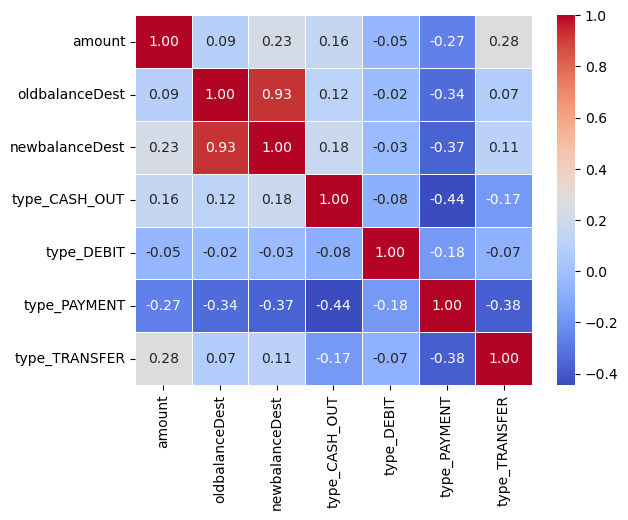

In [41]:
sns.heatmap(x.corr(),annot=True,fmt='.2f',cmap='coolwarm',linewidths='0.5')